## Imports

In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patheffects as pe
import seaborn as sns
from matplotlib.collections import LineCollection
from scipy.spatial.distance import cdist

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import (
    FIG_DIR,
    HEATMAP_CMAP, 
    PROCESSED_DIR,
    TRAJECTORY_CMAP
)
from analysis_helpers.functions import (
    draw_eventseg_episode,
    draw_eventseg_recall,
    mean_center, 
    show_source
)

## Functions

In [2]:
show_source(draw_eventseg_episode)

In [3]:
show_source(draw_eventseg_recall)

In [4]:
show_source(mean_center)

In [5]:
def smooth_trajectory(traj, window):
    return pd.DataFrame(traj).rolling(window).mean().loc[window:, :].to_numpy()

In [6]:
def draw_2d_traj(ax, traj):
    points = traj.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lines = LineCollection(segments, cmap=TRAJECTORY_CMAP)
    lines.set_array(np.linspace(0, 1, len(segments)))
    lines.set_linewidth(TRAJ_LINEWIDTH)
    lines.set_capstyle("round")
    lines.set_clip_on(False)
    lines.set_path_effects([
        pe.Stroke(linewidth=TRAJ_CASING_LINEWIDTH,
                  foreground=TRAJ_CASING_COLOR, 
                  capstyle="round"),
        pe.Normal()
    ])
    ax.add_collection(lines)
    ax.autoscale()
    return ax

In [7]:
def draw_events_path(ax, events_2d, colors):
    ax.plot(events_2d[:, 0], 
            events_2d[:, 1], 
            c="k", 
            linewidth=EVENTS_2D_PATH_LINEWIDTH, 
            zorder=1, 
            clip_on=False)
    ax.scatter(events_2d[:, 0], 
               events_2d[:, 1], 
               s=EVENTS_2D_DOTSIZE, 
               c=colors,
               cmap=None,
               edgecolors="k", 
               linewidths=EVENTS_2D_BORDER_LINEWIDTH, 
               zorder=2,
               clip_on=False)
    return ax

In [8]:
def axes_tight_square(ax, points):
    """Frame axes to plotted data with equal x/y spans"""
    (xmin, ymin) = points.min(0)
    (xmax, ymax) = points.max(0)
    x_center = (xmin + xmax) / 2
    y_center = (ymin + ymax) / 2
    mid = max(xmax - xmin, ymax - ymin) / 2
    ax.set_xlim(x_center - mid, x_center + mid)
    ax.set_ylim(y_center - mid, y_center + mid)
    ax.set_box_aspect(1)
    ax.axis("off")
    return ax

In [9]:
def style_heatmap_axes(ax):
    ax.xaxis.label.set_size(HEATMAP_LABEL_FONTSIZE)
    ax.yaxis.label.set_size(HEATMAP_LABEL_FONTSIZE)
    ax.tick_params(bottom=False, 
                   left=False, 
                   pad=HEATMAP_TICKLABEL_PAD, 
                   labelsize=HEATMAP_TICKLABEL_FONTSIZE)
    plt.setp(ax.get_yticklabels(), rotation=90, va="center")
    ax.set_box_aspect(1)
    return ax

## Load data

In [10]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

umap_reducer = pickle.loads((PROCESSED_DIR / 'umap_reducer.p').read_bytes())

## Create 2D trajectory projections

In [11]:
EXAMPLE_PARTICIPANT_N = 50

EPISODE_SMOOTH_WINDOW = 50
IMM_REC_SMOOTH_WINDOW = 10
DEL_REC_SMOOTH_WINDOW = 10

example_participant = participants[EXAMPLE_PARTICIPANT_N - 1]

ep_traj_centered = mean_center(atlep1.trajectory)
(imm_traj_centered, 
 del_traj_centered) = mean_center(example_participant.trajectories['atlep1'], 
                                  example_participant.trajectories['delayed'])

ep_traj_smoothed = smooth_trajectory(ep_traj_centered, EPISODE_SMOOTH_WINDOW)
imm_traj_smoothed = smooth_trajectory(imm_traj_centered, IMM_REC_SMOOTH_WINDOW)
del_traj_smoothed = smooth_trajectory(del_traj_centered, DEL_REC_SMOOTH_WINDOW)

to_embed = [ep_traj_smoothed, imm_traj_smoothed, del_traj_smoothed]
split_inds = np.cumsum([vec.shape[0] for vec in to_embed])[:-1]
stacked_trajs = np.vstack(to_embed)
stacked_embeddings = umap_reducer.transform(stacked_trajs)
ep_traj_2d, imm_traj_2d, del_traj_2d = np.vsplit(stacked_embeddings, split_inds)

## Construct figure

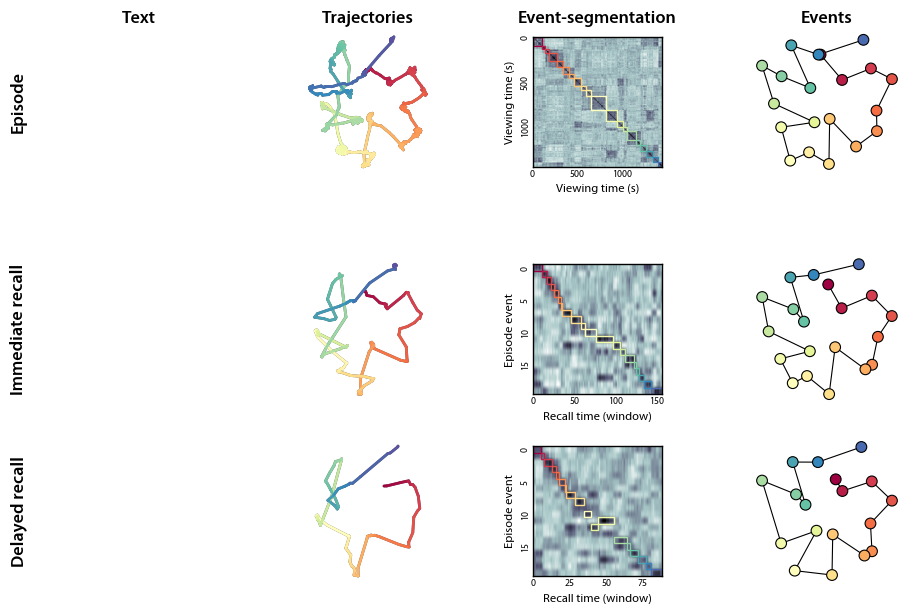

In [12]:
################################ CONFIG ################################

TRAJ_LINEWIDTH = 2
TRAJ_CASING_COLOR = "0.35"
TRAJ_CASING_LINEWIDTH = 2

EVENTSEG_LINEWIDTH = 1
HEATMAP_LABEL_FONTSIZE = 9
HEATMAP_TICKLABEL_FONTSIZE = 7
HEATMAP_TICKLABEL_PAD = -3
EP_HEATMAP_TICK_INTERVAL = 500

EVENTS_2D_DOTSIZE = 60
EVENTS_2D_BORDER_LINEWIDTH = 0.8
EVENTS_2D_PATH_LINEWIDTH = 0.8

FIGSIZE = (11, 7)
GRID_WSPACE = 0.4
GAP_EP_IMM = 0.75
GAP_IMM_DEL = 0.4

LABEL_FONTSIZE = 13
LABEL_FONTWEIGHT = "semibold"
COL_TITLE_PAD = 0.015          # figure-fraction gap above the top row
ROW_LABEL_PAD = 0.05           # figure-fraction gap left of the first column
COL_TITLES = ["Text", "Trajectories", "Event-segmentation", "Events"]
ROW_LABELS = ["Episode", "Immediate recall", "Delayed recall"]

N_EPISODE_EVENTS = len(atlep1.events)
EP_EVENTS_COLORS = TRAJECTORY_CMAP(
    np.arange(N_EPISODE_EVENTS) / N_EPISODE_EVENTS
)
IMM_REC_EVENTS_COLORS = TRAJECTORY_CMAP(
    example_participant.event_matches['atlep1'] / N_EPISODE_EVENTS
)
DEL_REC_EVENTS_COLORS = TRAJECTORY_CMAP(
    example_participant.event_matches['delayed'] / N_EPISODE_EVENTS
)

########################################################################


with sns.plotting_context("paper"):
    fig = plt.figure(figsize=FIGSIZE)
    gs = fig.add_gridspec(5, 4, 
                          hspace=0,
                          wspace=GRID_WSPACE, 
                          height_ratios=[1, GAP_EP_IMM, 1, GAP_IMM_DEL, 1])
    axarr = np.array([[fig.add_subplot(gs[r, c]) 
                       for c in range(4)] 
                      for r in (0, 2, 4)], 
                     dtype=object)
    (
        (_, ep_traj_ax, ep_eventseg_ax, ep_events_ax),
        (_, imm_traj_ax, imm_eventseg_ax, imm_events_ax),
        (_, del_traj_ax, del_eventseg_ax, del_events_ax)
    ) = axarr

    # ======== COLUMN 1: annotation/transcript text placeholder ========
    for ax in axarr[:, 0]:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_box_aspect(1)
        ax.axis('off')

        
    # ===================== COLUMN 2: trajectories =====================
    # episode
    draw_2d_traj(ep_traj_ax, ep_traj_2d)
    axes_tight_square(ep_traj_ax, ep_traj_2d)
    
    # immediate recall
    draw_2d_traj(imm_traj_ax, imm_traj_2d)
    axes_tight_square(imm_traj_ax, imm_traj_2d)
    
    # delayed recall
    draw_2d_traj(del_traj_ax, del_traj_2d)
    axes_tight_square(del_traj_ax, del_traj_2d)
    
    
    # ================== COLUMN 3: EVENT-SEGMENTATION ==================
    # episode
    ep_corrmat = np.corrcoef(ep_traj_centered)
    ep_eventseg_ax.imshow(ep_corrmat, cmap=HEATMAP_CMAP)
    draw_eventseg_episode(ep_eventseg_ax, 
                          atlep1.event_bounds, 
                          edgecolor=EP_EVENTS_COLORS, 
                          linewidth=EVENTSEG_LINEWIDTH)
    ep_eventseg_ax.set_xlabel('Viewing time (s)')
    ep_eventseg_ax.set_ylabel('Viewing time (s)')
    ep_corrmat_ticks = np.arange(0, len(ep_corrmat), EP_HEATMAP_TICK_INTERVAL)
    ep_eventseg_ax.set_xticks(ep_corrmat_ticks)
    ep_eventseg_ax.set_yticks(ep_corrmat_ticks)
    style_heatmap_axes(ep_eventseg_ax)
    
    # immediate recall
    ep_events_centered = mean_center(atlep1.events)
    cosmat = 1 - cdist(imm_traj_centered, ep_events_centered, metric='cosine')
    aspect_ratio = cosmat.shape[0] / cosmat.shape[1]
    imm_eventseg_ax.imshow(cosmat.T, cmap=HEATMAP_CMAP, aspect=aspect_ratio)
    draw_eventseg_recall(imm_eventseg_ax, 
                         example_participant.event_bounds['atlep1'], 
                         example_participant.event_matches['atlep1'], 
                         edgecolor=IMM_REC_EVENTS_COLORS, 
                         linewidth=EVENTSEG_LINEWIDTH)
    imm_eventseg_ax.set_xlabel('Recall time (window)')
    imm_eventseg_ax.set_ylabel('Episode event')
    style_heatmap_axes(imm_eventseg_ax)
    
    # delayed recall
    cosmat = 1 - cdist(del_traj_centered, ep_events_centered, metric='cosine')
    aspect_ratio = cosmat.shape[0] / cosmat.shape[1]
    del_eventseg_ax.imshow(cosmat.T, cmap=HEATMAP_CMAP, aspect=aspect_ratio)
    draw_eventseg_recall(del_eventseg_ax, 
                         example_participant.event_bounds['delayed'], 
                         example_participant.event_matches['delayed'], 
                         edgecolor=DEL_REC_EVENTS_COLORS, 
                         linewidth=EVENTSEG_LINEWIDTH)
    del_eventseg_ax.set_xlabel('Recall time (window)')
    del_eventseg_ax.set_ylabel('Episode event')
    style_heatmap_axes(del_eventseg_ax)
    
    
    # ===================== COLUMN 4: EVENT PATHS ======================
    # episode
    draw_events_path(ep_events_ax, atlep1.path_2d, EP_EVENTS_COLORS)
    axes_tight_square(ep_events_ax, atlep1.path_2d)
    
    # immediate recall
    draw_events_path(imm_events_ax, 
                     example_participant.paths_2d['atlep1'], 
                     IMM_REC_EVENTS_COLORS)
    axes_tight_square(imm_events_ax, example_participant.paths_2d['atlep1'])
    
    # delayed recall
    draw_events_path(del_events_ax, 
                     example_participant.paths_2d['delayed'], 
                     DEL_REC_EVENTS_COLORS)
    axes_tight_square(del_events_ax, example_participant.paths_2d['delayed'])
    

    # add row/column labels
    for col_ix, title in enumerate(COL_TITLES):
        p = axarr[0, col_ix].get_position()
        fig.text((p.x0 + p.x1) / 2, 
                 p.y1 + COL_TITLE_PAD, 
                 title,
                 ha="center", 
                 va="bottom",
                 fontsize=LABEL_FONTSIZE, 
                 fontweight=LABEL_FONTWEIGHT)
    for row_ix, label in enumerate(ROW_LABELS):
        p = axarr[row_ix, 0].get_position()
        fig.text(p.x0 - ROW_LABEL_PAD, 
                 (p.y0 + p.y1) / 2, 
                 label,
                 ha="center", 
                 va="center", 
                 rotation=90,
                 fontsize=LABEL_FONTSIZE, 
                 fontweight=LABEL_FONTWEIGHT)
        
#     plt.savefig(FIG_DIR / 'pipeline-overview.pdf', bbox_inches='tight')
    plt.show()